In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

In [97]:
data = pd.read_csv('datasets/sample_dataset.csv')

In [98]:
data.isna().sum()

Customer ID              0
Name                     0
Surname                  0
Gender                5047
Birthdate                0
Transaction Amount       0
Date                     0
Merchant Name            0
Category                 0
dtype: int64

In [99]:
# data.head()

In [100]:
print(data['Gender'].value_counts())
print(f"Missing Gender: {len(data[data['Gender'].isna()]) } / {len(data)} {len(data[data['Gender'].isna()]) / len(data) * 100:.2f}%")

Gender
F    22713
M    22240
Name: count, dtype: int64
Missing Gender: 5047 / 50000 10.09%


In [88]:
missing_gender = data[data['Gender'].isna()]
known_gender = data[data['Gender'].notna()]

In [89]:
merged = missing_gender.merge(known_gender, how='inner', on=['Name', 'Surname'], 
                              suffixes=['', '_k'])

In [90]:
# merged.head()

In [101]:
df = data.copy()
df['Gender'] = data.groupby(['Name', 'Surname'])['Gender'].transform(lambda x: x.ffill().bfill())

In [102]:
df.isna().sum()

Customer ID              0
Name                     0
Surname                  0
Gender                3414
Birthdate                0
Transaction Amount       0
Date                     0
Merchant Name            0
Category                 0
dtype: int64

In [103]:
df['Gender'] = data['Gender'].fillna(data.groupby('Name')['Gender'].transform('first'))

In [104]:
df.isna().sum()

Customer ID           0
Name                  0
Surname               0
Gender                0
Birthdate             0
Transaction Amount    0
Date                  0
Merchant Name         0
Category              0
dtype: int64

In [105]:
df.head()

,Customer ID,Name,Surname,Gender,Birthdate,Transaction Amount,Date,Merchant Name,Category
0,752858,Sean,Rodriguez,F,2002-10-20,35.47,2023-04-03,Smith-Russell,Cosmetic
1,26381,Michelle,Phelps,M,1985-10-24,2552.72,2023-07-17,"Peck, Spence and Young",Travel
2,305449,Jacob,Williams,M,1981-10-25,115.97,2023-09-20,Steele Inc,Clothing
3,988259,Nathan,Snyder,M,1977-10-26,11.31,2023-01-11,"Wilson, Wilson and Russell",Cosmetic
4,764762,Crystal,Knapp,F,1951-11-02,62.21,2023-06-13,Palmer-Hinton,Electronics


In [106]:
df['Category'].unique()

<StringArray>
['Cosmetic', 'Travel', 'Clothing', 'Electronics', 'Restaurant', 'Market']
Length: 6, dtype: str

In [115]:
df_encoded = pd.get_dummies(df, columns=['Category'], dtype=int)
df_encoded['Gender'] = df_encoded['Gender'].map({'M': 0, 'F': 1})

In [116]:
df_encoded.head()

,Customer ID,Name,Surname,Gender,Birthdate,Transaction Amount,Date,Merchant Name,Category_Clothing,Category_Cosmetic,Category_Electronics,Category_Market,Category_Restaurant,Category_Travel
0,752858,Sean,Rodriguez,1,2002-10-20,35.47,2023-04-03,Smith-Russell,0,1,0,0,0,0
1,26381,Michelle,Phelps,0,1985-10-24,2552.72,2023-07-17,"Peck, Spence and Young",0,0,0,0,0,1
2,305449,Jacob,Williams,0,1981-10-25,115.97,2023-09-20,Steele Inc,1,0,0,0,0,0
3,988259,Nathan,Snyder,0,1977-10-26,11.31,2023-01-11,"Wilson, Wilson and Russell",0,1,0,0,0,0
4,764762,Crystal,Knapp,1,1951-11-02,62.21,2023-06-13,Palmer-Hinton,0,0,1,0,0,0


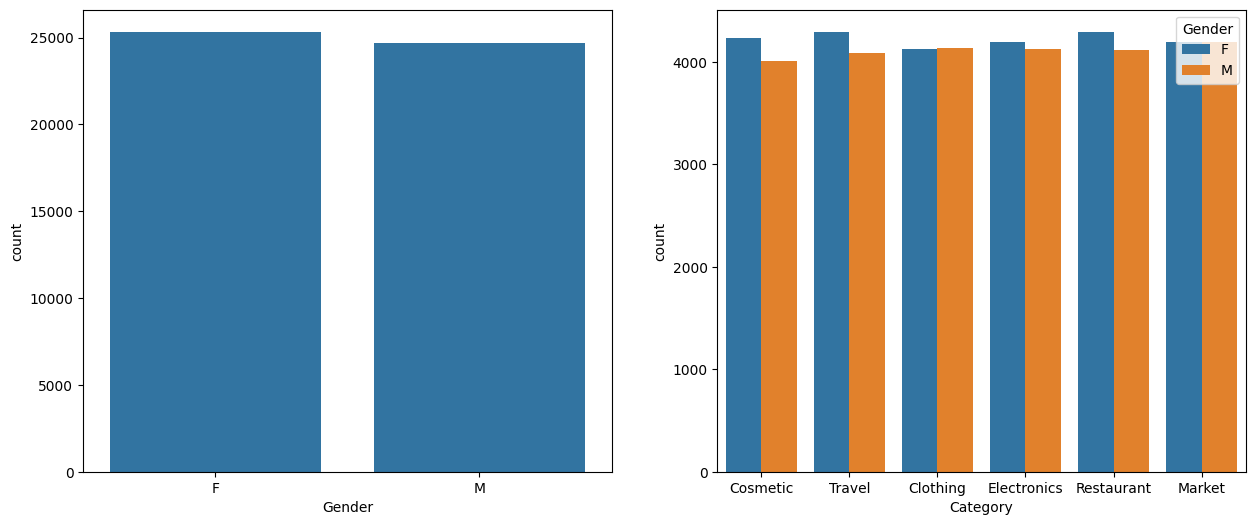

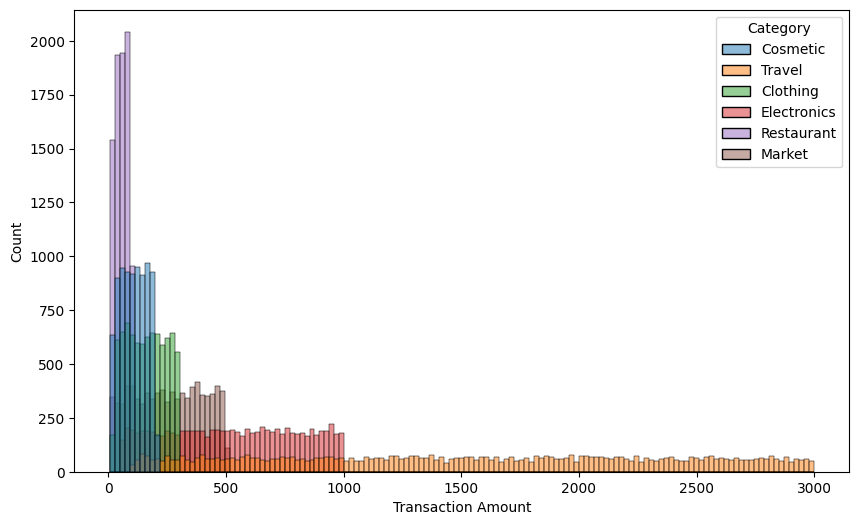

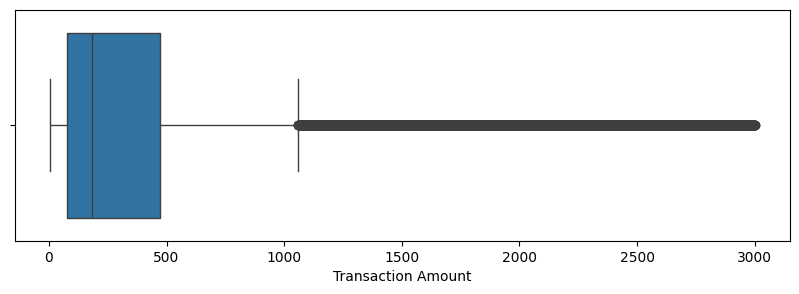

,Customer ID,Transaction Amount
count,50000.00000,50000.000000
mean,500136.79696,442.119239
std,288232.43164,631.669724
min,29.00000,5.010000
25%,251191.50000,79.007500
50%,499520.50000,182.195000
75%,749854.25000,470.515000
max,999997.00000,2999.880000


In [127]:
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
sns.countplot(df, x='Gender')
plt.subplot(1,2,2)
sns.countplot(df, x='Category', hue='Gender')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df, x='Transaction Amount', hue='Category')
plt.show()

plt.figure(figsize=(10, 3))
sns.boxplot(df, x='Transaction Amount')
plt.show()
df.describe()

In [117]:
from sklearn.preprocessing import StandardScaler
features = df_encoded[['Gender', 'Transaction Amount', 
                       'Category_Clothing', 'Category_Cosmetic', 'Category_Electronics',
                       'Category_Market', 'Category_Restaurant', 'Category_Travel'
                      ]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [133]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, n_init=10)
k_clusters = kmeans.fit_predict(scaled_features)

df['Cluster'] = k_clusters

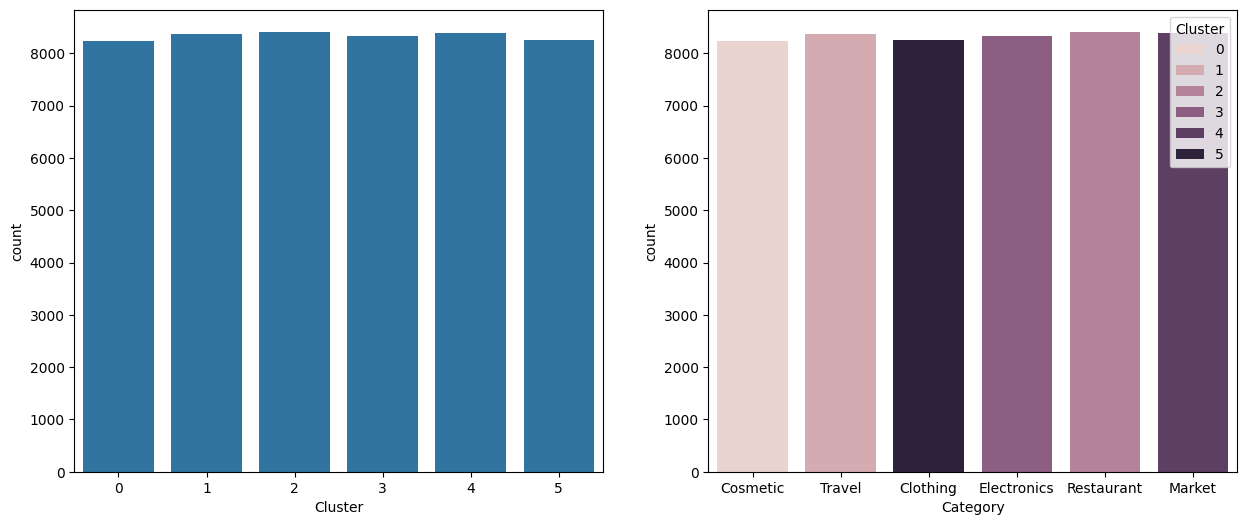

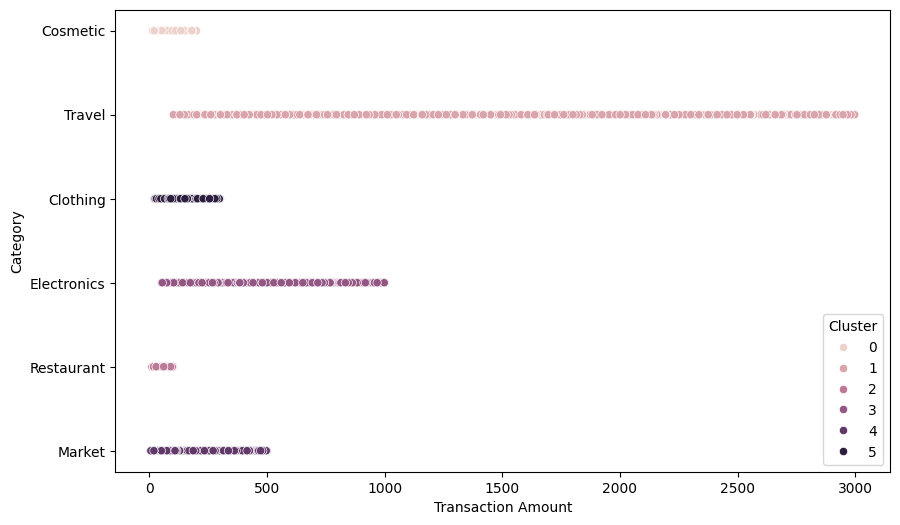

In [134]:
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
sns.countplot(df, x='Cluster')
plt.subplot(1,2,2)
sns.countplot(df, x='Category', hue='Cluster')
plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(df, x='Transaction Amount', y='Category', hue='Cluster')
plt.show()